PCA Train Shape: (433132, 2)
PCA Test Shape: (108284, 2)

Cluster labels for TRAIN data:
[2 2 2 ... 2 1 0]

Cluster labels for TEST data:
[1 0 1 ... 2 2 2]


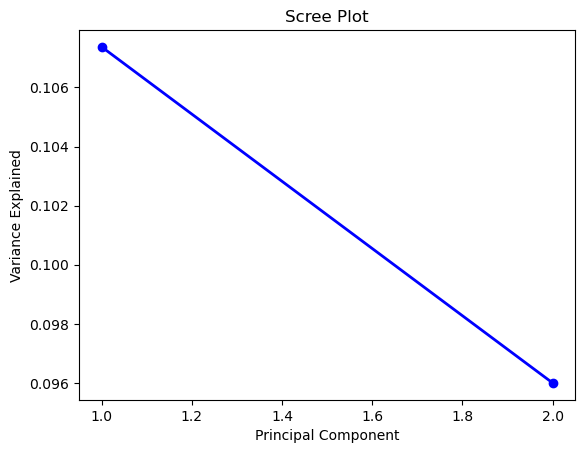

In [97]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# --------------------------
# 1. Load your dataset
# --------------------------
df = pd.read_csv("../data/claims_train.csv")   # replace with your file

df = df[df["Exposure"] <= 1]

X = X = df[['Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas', 'VehBrand']]

X = pd.get_dummies(X, drop_first=True)

y = df["ClaimNb"]

# Select features
# X = df.drop(columns=['target'], errors='ignore')  # or select columns manually

# --------------------------
# 2. Train/test split
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# --------------------------
# 3. Scaling (fit on TRAIN only)
# --------------------------
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------
# 5. Clustering (fit on TRAIN only)
# --------------------------
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_train_scaled)

train_clusters = kmeans.labels_
test_clusters  = kmeans.predict(X_test_scaled)

# --------------------------
# 6. Output results
# --------------------------
print("PCA Train Shape:", X_train_pca.shape)
print("PCA Test Shape:", X_test_pca.shape)

print("\nCluster labels for TRAIN data:")
print(train_clusters)

print("\nCluster labels for TEST data:")
print(test_clusters)

per_var = pca.explained_variance_ratio_ *100

PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()


In [105]:
X_train["Labels"] = train_clusters
X_train["ClaimNb"] = y_train

X_train

,Density,DrivAge,Exposure,VehAge,VehPower,BonusMalus,VehGas_Regular,VehBrand_B10,VehBrand_B11,VehBrand_B12,VehBrand_B13,VehBrand_B14,VehBrand_B2,VehBrand_B3,VehBrand_B4,VehBrand_B5,VehBrand_B6,Labels,ClaimNb
238044,108,47,0.70,9,6,50,False,False,False,False,False,False,True,False,False,False,False,2,0
331974,44,78,1.00,13,6,50,True,False,False,False,False,False,False,True,False,False,False,2,0
48861,96,54,1.00,6,5,50,False,False,False,False,False,False,True,False,False,False,False,2,0
231459,27000,48,0.60,10,10,50,False,False,False,True,False,False,False,False,False,False,False,0,0
402115,32,60,0.05,13,4,50,True,False,False,False,False,False,False,False,False,False,True,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110480,95,54,0.12,0,8,50,True,False,False,False,False,False,False,False,False,True,False,2,0
259668,43,53,0.72,7,5,50,False,False,False,False,False,False,False,False,True,False,False,1,0
366511,43,26,1.00,5,5,54,False,False,False,False,False,False,False,False,False,False,False,2,0
132182,1445,30,1.00,2,7,85,False,False,False,False,False,False,False,False,False,True,False,1,0


In [ ]:
import matplotlib.pyplot as plt
label_0= X_train[X_train["Labels"] == 0]
label_1= X_train[X_train["Labels"] == 1]
label_2= X_train[X_train["Labels"] == 2]
label_3= X_train[X_train["Labels"] == 3]



In [100]:
plt.hist(label_0["Y"])

KeyError: 'Y'

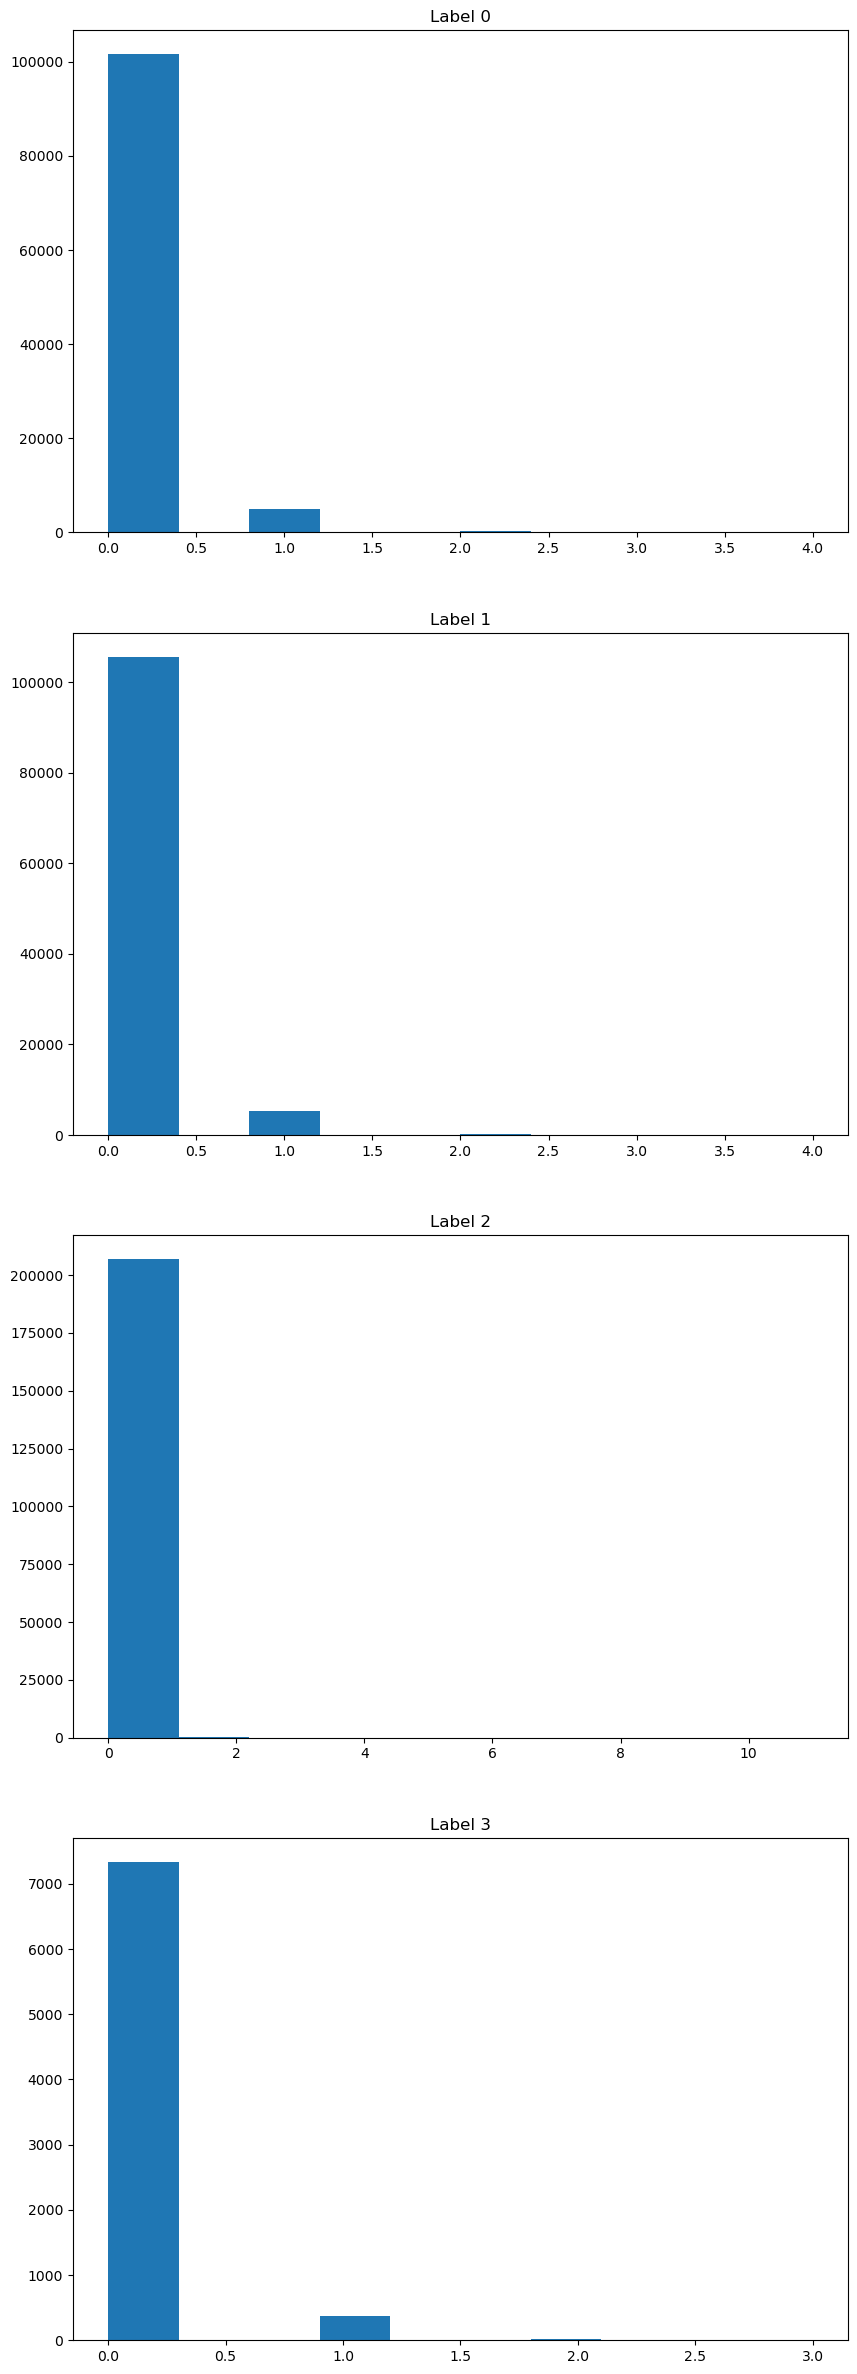

In [108]:
fig, ax = plt.subplots(4,1,figsize = (10,30))

count = 0
column = 0

l = [label_0,label_1, label_2, label_3]

for label in l:
    ax[count].hist(label["ClaimNb"])
    ax[count].set_title(f"Label {count}")
    count += 1

plt.show()

In [118]:
count = 0
for cluster in l:

    mC = np.mean(cluster["ClaimNb"])
    varC = np.var(cluster["ClaimNb"])
    stdC = np.std(cluster["ClaimNb"])

    mBM = np.mean(cluster["BonusMalus"])
    varBM = np.var(cluster["BonusMalus"])
    stdBM = np.std(cluster["BonusMalus"])

    mDA = np.mean(cluster["DrivAge"])
    varDA = np.var(cluster["DrivAge"])
    stdDA = np.std(cluster["DrivAge"])

    print(f"Cluster {count}")
    print(f"Claims: mean; {mC}, var; {varC}, std; {stdC}")
    print(f"BonusMalus: mean;{mBM}, var; {varBM}, std; {stdBM}")
    print(f"Drivers age: mean;{mDA}, var; {varDA}, std; {stdDA}")
    print()



    count += 1




Cluster 0
Claims: mean; 0.052697099319524134, var; 0.05729583693684959, std; 0.23936548819086179
BonusMalus: mean;58.63341351778878, var; 215.34739500765164, std; 14.674719588723038
Drivers age: mean;47.520269195129025, var; 183.59558352497734, std; 13.549744777115816

Cluster 1
Claims: mean; 0.05494831194259078, var; 0.05902431474054876, std; 0.2429492019755339
BonusMalus: mean;72.7178846965628, var; 385.65112111635204, std; 19.638001963447095
Drivers age: mean;36.301299611104625, var; 142.14732490245103, std; 11.922555300876194

Cluster 2
Claims: mean; 0.05292772142491772, var; 0.05646728089806298, std; 0.23762845136486282
BonusMalus: mean;53.431297231042436, var; 54.248976376957934, std; 7.36539044294041
Drivers age: mean;49.415203690656575, var; 178.19319225989713, std; 13.348902286701223

Cluster 3
Claims: mean; 0.05447722567287785, var; 0.05875583436745126, std; 0.24239602795312315
BonusMalus: mean;58.54050207039337, var; 203.69996413715273, std; 14.27234963617248
Drivers age: me

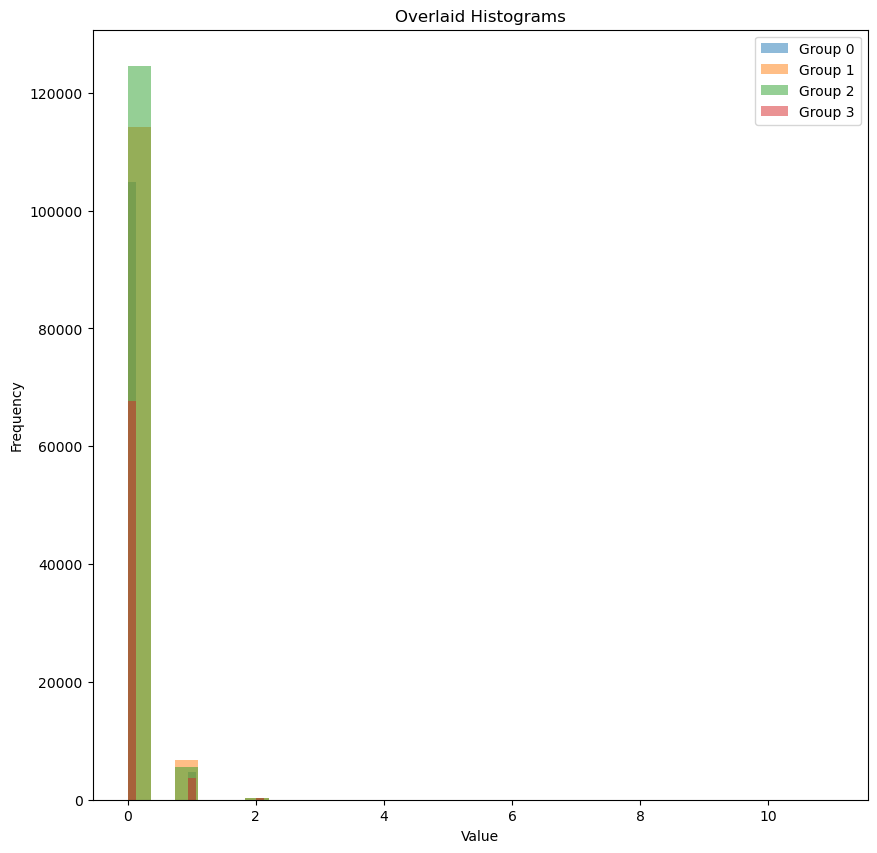

In [92]:
feature = "ClaimNb"
plt.figure(figsize=(10,10))
plt.hist(label_0[feature], bins=30, alpha=0.5, label='Group 0')
plt.hist(label_1[feature], bins=30, alpha=0.5, label='Group 1')
plt.hist(label_2[feature], bins=30, alpha=0.5, label='Group 2')
plt.hist(label_3[feature], bins=30, alpha=0.5, label='Group 3')


plt.legend()
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Overlaid Histograms")
plt.show()